1. Load the Foreign gifts data

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


2. Describe the differences between different classes of gift types

In [7]:
print(df['Gift Type'].unique())

['Monetary Gift' 'Contract' 'Real Estate']



A Monetary gift is when someone gives money to the university without expecting anything in return.
A contract when someone pays the university with the expectation that the university will do something for them in return.
A Real estate gift is a donation of land or property to the university

3.1. Which country gives the most money in total?

In [13]:
print(df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False))

Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
                   ...    
IRAN                    80
ST. LUCIA               50
CROATIA                 26
SLOVAKIA                20
ERITREA                  3
Name: Foreign Gift Amount, Length: 155, dtype: int64


Qatar gives the most money in total

3.2.  Which country initiates the most gifts by count?

In [14]:
print(df.groupby('Country of Giftor').size().sort_values(ascending=False))

Country of Giftor
ENGLAND        3655
CHINA          2461
CANADA         2344
JAPAN          1896
SWITZERLAND    1676
               ... 
ERITREA           1
ARMENIA           1
ANTIGUA           1
PALAU             1
ROMANIA           1
Length: 155, dtype: int64


England initiates the most gifts by count

3.3.  Which country gives the largest gifts on average?

In [19]:
x = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False)
y = df.groupby('Country of Giftor').size().sort_values(ascending=False)
z = x/y
print(z.sort_values(ascending=False))

Country of Giftor
BERMUDA      7.688837e+06
ECUADOR      3.985140e+06
QATAR        3.905109e+06
ANTIGUA      3.435545e+06
JERSEY       3.064589e+06
                 ...     
ST. LUCIA    5.000000e+01
IRAN         4.000000e+01
CROATIA      2.600000e+01
SLOVAKIA     2.000000e+01
ERITREA      3.000000e+00
Length: 155, dtype: float64


On average, Bermuda gives the largest gifts

3.4. Which institution received the most money in total?

In [20]:
print(df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False))

Institution Name
Carnegie Mellon University               1477922504
Cornell University                       1289937761
Harvard University                        954803610
Massachusetts Institute of Technology     859071692
Yale University                           613441311
                                            ...    
Bates College                                250000
Metropolitan State University                235439
University of California, Merced             182514
University of Central Oklahoma               160288
University of Jamestown                         500
Name: Foreign Gift Amount, Length: 318, dtype: int64


Carnegie Mellon University

3.5. Which institution receive the greatest number of gifts by count?

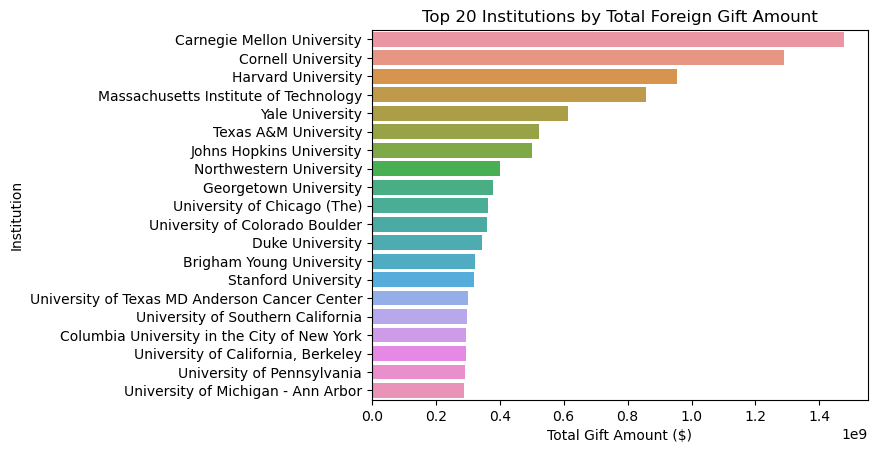

In [24]:
top20 = df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(20)

sns.barplot(x=top20.values, y=top20.index)
plt.xlabel('Total Gift Amount ($)')
plt.ylabel('Institution')
plt.title('Top 20 Institutions by Total Foreign Gift Amount')
plt.show()

Carnegie Mellon University

3.6. What is the average amount each university receives? Median amount? If they are different why?

In [27]:
mean = df.groupby('Institution Name')['Foreign Gift Amount'].mean().sort_values(ascending=False)
print(mean)

median = df.groupby('Institution Name')['Foreign Gift Amount'].median().sort_values(ascending=False)
print(median)

Institution Name
Brigham Young University - Idaho       2.270552e+07
Western International University       1.294216e+07
Whittier College                       1.207900e+07
University of Phoenix                  1.109435e+07
Curtis Institute of Music              1.000000e+07
                                           ...     
University of Alabama at Birmingham    2.983812e+04
University of California, Merced       1.520950e+04
Marquette University                   1.404990e+04
Westminster Theological Seminary       7.695829e+03
University of Jamestown                5.000000e+02
Name: Foreign Gift Amount, Length: 318, dtype: float64
Institution Name
Brigham Young University - Idaho         22794050.5
Curtis Institute of Music                10000000.0
Juilliard School (The)                    5570000.0
Indiana State University                  4291189.0
Midwestern State University               4200000.0
                                            ...    
University of Jamestown    

They're probably different because there will be some massive donations that skew the mean to the right, so with this kind of dataset, the median will typically be smaller than the mean

3.7. What is the largest flow of a single country to a single institution?

In [ ]:
ct = pd.crosstab(
    df['Country of Giftor'],
    df['Institution Name'],
    values=df['Foreign Gift Amount'],
    aggfunc='sum'
)

top_flows = ct.stack().sort_values(ascending=False).head(5)
print(top_flows)

Country of Giftor     Institution Name                     
QATAR                 Cornell University                       1.018473e+09
BERMUDA               Carnegie Mellon University               7.500000e+08
QATAR                 Texas A&M University                     5.040994e+08
                      Carnegie Mellon University               4.254107e+08
                      Georgetown University                    3.271283e+08
                      Northwestern University                  3.111486e+08
CANADA                Brigham Young University                 2.599278e+08
UNITED ARAB EMIRATES  University of Colorado Boulder           2.197348e+08
ENGLAND               Harvard University                       1.883283e+08
HONG KONG             Yale University                          1.611312e+08
INDIA                 University of Phoenix                    1.520000e+08
AUSTRALIA             Northeastern University                  1.483555e+08
HONG KONG             Harvar

The largest flow of a single country to a single institution is from Qatar to Cornell University

3.8. Which are the top giftors to US academic institutions?

In [36]:
import plotly.graph_objects as go

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

The top 5 giftors to individual US academic institutions are in order: Qatar, Bermuda, UAE, Canada, and India